# Washington streamflow, year over year — Yakima River basin (HUC4 1703)

This notebook picks a Washington water basin, reconstructs its **year-by-year monthly flow** from real PRISM climate (2014–2023), shows how the seasonal hydrograph shifts between wet and dry years, and fits a simple **flow prediction**.

It drives this repo's own offline engine `src.historical_flow.yearly_flow_series` with the real PRISM provider `tools.historical_flow.PrismClimateProvider`. Flow is *modeled, not gauged*: NHDPlus HR gives each reach a **mean-annual** discharge (`QIncrAMA`, cfs), and the model redistributes that annual total across the 12 months using each year's snow-aware precipitation + temperature.

> **Key property baked into the model:** it *conserves* each reach's annual mean. So the year-over-year signal lives in **seasonal timing and peak flow**, not the annual total (which is fixed by construction). The graphs below lean into that.

In [1]:
import sys, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

from src.historical_flow import yearly_flow_series
from src.monthly_flow import MONTH_ABBR
from tools.historical_flow import PrismClimateProvider, DEFAULT_ROOT

# --- pick a basin + year span ------------------------------------------
HUC4 = "1703"                    # 1703 = Yakima River basin (WA)
BASIN_NAME = "Yakima River basin"
YEARS = list(range(2014, 2024))  # PRISM grids staged on the NAS for 2014–2023

print(f"repo  : {REPO}")
print(f"basin : {BASIN_NAME} (HUC4 {HUC4})")
print(f"years : {YEARS[0]}–{YEARS[-1]}")
print(f"PRISM : {DEFAULT_ROOT}/prism")

repo  : /Users/neilrunde/code/hydro-art
basin : Yakima River basin (HUC4 1703)
years : 2014–2023
PRISM : /Volumes/home/data/hydro-art/prism


## 1 · Load the basin's river network

Reuses the cached topology + centroids that `tools/render_state_yoy.py` staged (`output/_yoy_net_<huc4>.pkl`): each reach's incremental annual flow (`QIncrAMA`), the `HydroSeq`/`DnHydroSeq` connectivity, and a representative lon/lat in PRISM's CRS (EPSG:4269). Falls back to reading the GDB directly if no cache exists (needs the full GIS env + datasets on disk).

In [2]:
net_cache = REPO / f"output/_yoy_net_{HUC4}.pkl"
if net_cache.exists():
    ids, q_incr, hydroseq, dnhydroseq, lon, lat = pickle.loads(
        net_cache.read_bytes()
    )
else:
    from tools.render_state_yoy import build_network
    from tools.render_common import gdb_paths
    ids, q_incr, hydroseq, dnhydroseq, lon, lat = build_network(
        gdb_paths(HUC4)[0]
    )

n = len(ids)
print(f"{n:,} reaches")
print(f"extent: lon [{lon.min():.2f}, {lon.max():.2f}]  "
      f"lat [{lat.min():.2f}, {lat.max():.2f}]")

62,633 reaches
extent: lon [-121.50, -119.21]  lat [45.98, 47.59]


## 2 · Reconstruct year-by-year monthly flow from PRISM

For each year the provider samples that year's 12 monthly precip + temperature grids at every catchment, and the shared `disaggregate_monthly` model turns them into **accumulated monthly flow** `[n_reaches, 12]` in cfs (the provider is called once per year). ~1 minute for the full Yakima basin × 10 years.

In [3]:
provider = PrismClimateProvider(DEFAULT_ROOT, lon, lat)
series = yearly_flow_series(
    provider, YEARS,
    q_incr=q_incr, hydroseq=hydroseq, dnhydroseq=dnhydroseq,
    latest=YEARS[-1],
)  # {year: flow[n, 12]} in cfs
print("years computed:", list(series))
print("per-year shape:", series[YEARS[0]].shape)

years computed: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
per-year shape: (62633, 12)


## 3 · Pick the stream

"The basin's river" = its **outlet reach**: the reach whose accumulated flow is largest, since every upstream tributary drains through it. We find it once from the decade-mean flow, then tabulate its monthly flow (rows = years, columns = Jan…Dec).

In [4]:
mean_flow_per_reach = np.mean(
    [series[y].mean(axis=1) for y in YEARS], axis=0
)  # [n]
outlet = int(mean_flow_per_reach.argmax())
print(f"outlet reach : NHDPlusID {int(ids[outlet])}")
print(f"location     : lon {lon[outlet]:.3f}, lat {lat[outlet]:.3f}")
print(f"mean flow    : {mean_flow_per_reach[outlet]:,.0f} cfs")

flow = pd.DataFrame(
    {MONTH_ABBR[m]: [series[y][outlet, m] for y in YEARS] for m in range(12)},
    index=pd.Index(YEARS, name="year"),
)
flow.round(0)

outlet reach : NHDPlusID 55001000055232
location     : lon -119.244, lat 46.249
mean flow    : 6,373 cfs


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2014,4005.0,38.0,11241.0,21656.0,18716.0,1689.0,1259.0,2878.0,1750.0,9196.0,3329.0,725.0
2015,6943.0,19454.0,20421.0,6635.0,8323.0,520.0,461.0,1202.0,1624.0,6095.0,4675.0,128.0
2016,108.0,8479.0,10145.0,25654.0,3676.0,2454.0,1374.0,377.0,2167.0,14887.0,7160.0,0.0
2017,0.0,17.0,8598.0,18487.0,30419.0,2330.0,1.0,201.0,1436.0,10721.0,4268.0,2.0
2018,2009.0,416.0,5664.0,29026.0,21335.0,1838.0,122.0,263.0,1279.0,7119.0,6933.0,477.0
2019,1497.0,0.0,2549.0,29356.0,19887.0,1818.0,1289.0,1692.0,5556.0,9033.0,3666.0,138.0
2020,1121.0,2337.0,4760.0,28095.0,20045.0,2855.0,191.0,198.0,3290.0,8072.0,5023.0,494.0
2021,2569.0,170.0,9345.0,25673.0,12058.0,3074.0,27.0,623.0,2799.0,7224.0,12780.0,139.0
2022,2035.0,1950.0,21858.0,6735.0,21528.0,17695.0,531.0,135.0,459.0,3326.0,227.0,0.0


## 4 · Where is it? Basin map

Every reach centroid, colored by log mean flow — the bright spine is the mainstem; the red star is the outlet we picked.

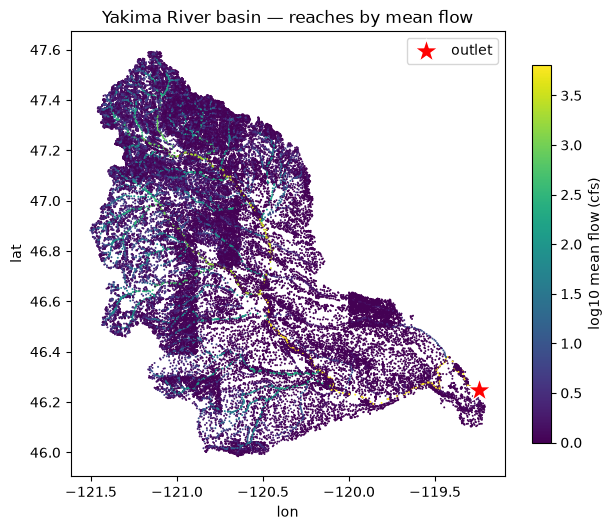

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(lon, lat, c=np.log10(mean_flow_per_reach + 1), s=2,
                cmap="viridis", linewidths=0)
ax.scatter(lon[outlet], lat[outlet], marker="*", s=320,
           edgecolor="white", facecolor="red", zorder=5, label="outlet")
ax.set_aspect(1 / np.cos(np.deg2rad(lat.mean())))
ax.set_title(f"{BASIN_NAME} — reaches by mean flow")
ax.set_xlabel("lon"); ax.set_ylabel("lat"); ax.legend(loc="upper right")
fig.colorbar(sc, ax=ax, label="log10 mean flow (cfs)", shrink=0.7)
plt.show()

## 5 · How the hydrograph shifts, year over year

Each line is one year's monthly flow at the outlet. Watch the spring freshet (snowmelt) shift earlier/later and rise/fall between wet and dry years — the part of the signal the annual total hides.

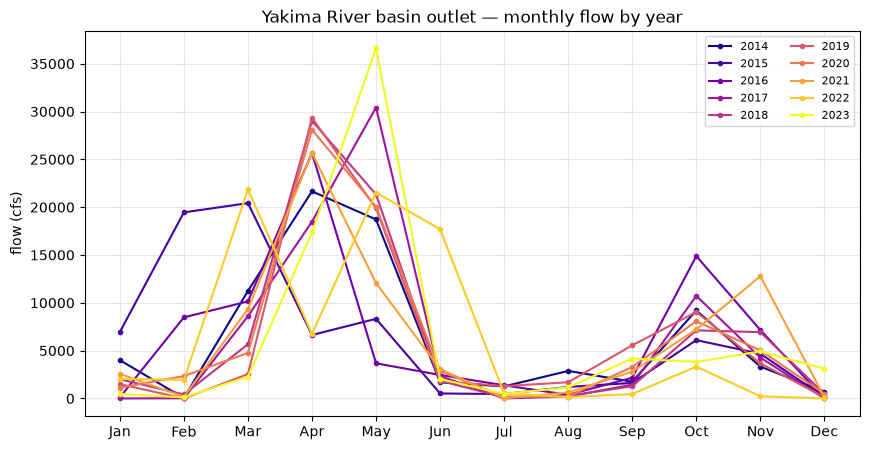

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.cm.plasma
for i, y in enumerate(YEARS):
    ax.plot(MONTH_ABBR, series[y][outlet], marker="o", ms=3,
            color=cmap(i / (len(YEARS) - 1)), label=str(y))
ax.set_ylabel("flow (cfs)")
ax.set_title(f"{BASIN_NAME} outlet — monthly flow by year")
ax.legend(ncol=2, fontsize=8); ax.grid(alpha=0.3)
plt.show()

## 6 · Why the annual total is flat — and what actually varies

The model conserves each reach's mean-annual flow, so the **annual mean is identical every year** (left). The real year-over-year signal is the **seasonal peak** (right): wet years spike higher, droughts thin out, and the peak month drifts.

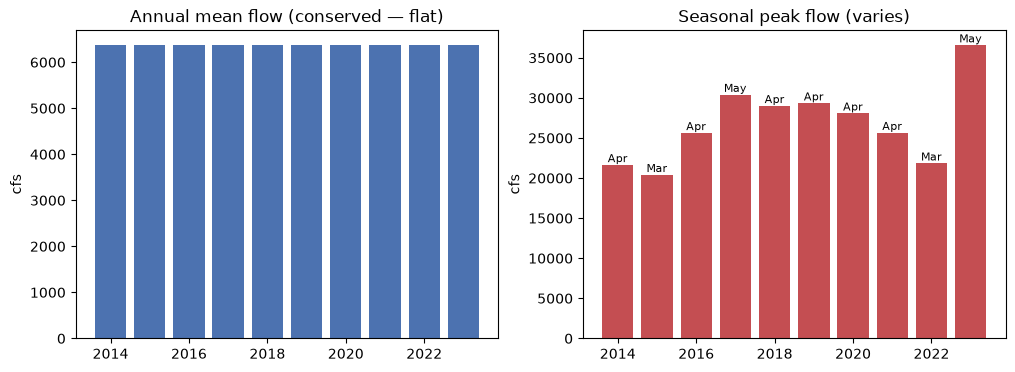

annual mean spread: 6,373..6,373 cfs (flat)
peak flow spread  : 20,421..36,595 cfs


In [7]:
annual_mean = flow.mean(axis=1)     # flat by construction
peak_flow = flow.max(axis=1)        # varies year to year
peak_month = flow.idxmax(axis=1)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.bar(YEARS, annual_mean, color="#4c72b0")
a1.set_title("Annual mean flow (conserved — flat)"); a1.set_ylabel("cfs")
a2.bar(YEARS, peak_flow, color="#c44e52")
for xx, pf, pm in zip(YEARS, peak_flow, peak_month):
    a2.text(xx, pf, pm, ha="center", va="bottom", fontsize=8)
a2.set_title("Seasonal peak flow (varies)"); a2.set_ylabel("cfs")
plt.show()
print(f"annual mean spread: {annual_mean.min():,.0f}..{annual_mean.max():,.0f} "
      f"cfs (flat)")
print(f"peak flow spread  : {peak_flow.min():,.0f}..{peak_flow.max():,.0f} cfs")

## 7 · Predict the seasonal peak flow

An ordinary-least-squares trend on peak flow vs. year, extrapolated 5 years with a ±1σ band from the fit residuals. This is a **statistical trend on a climate-driven model**, not a gauge forecast — 10 points with high interannual variance, so read the *band*, not the point estimate.

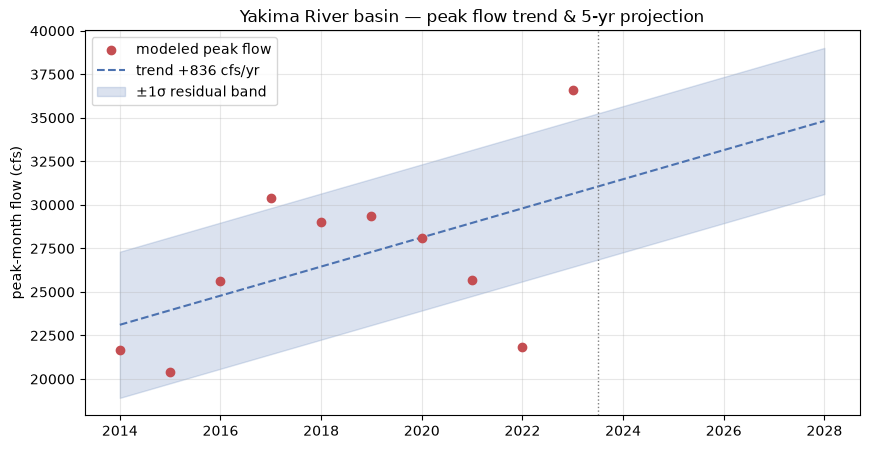

projection:
  2024: 31,474 ± 4,198 cfs
  2025: 32,310 ± 4,198 cfs
  2026: 33,146 ± 4,198 cfs
  2027: 33,982 ± 4,198 cfs
  2028: 34,818 ± 4,198 cfs


In [8]:
x = np.array(YEARS, dtype=float)
y = peak_flow.to_numpy(dtype=float)
slope, intercept = np.polyfit(x, y, 1)
resid_std = (y - (slope * x + intercept)).std(ddof=1)

future = np.arange(YEARS[0], YEARS[-1] + 6)
pred = slope * future + intercept

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, color="#c44e52", zorder=5, label="modeled peak flow")
ax.plot(future, pred, "--", color="#4c72b0",
        label=f"trend {slope:+,.0f} cfs/yr")
ax.fill_between(future, pred - resid_std, pred + resid_std, alpha=0.2,
                color="#4c72b0", label="±1σ residual band")
ax.axvline(YEARS[-1] + 0.5, color="gray", ls=":", lw=1)
ax.set_ylabel("peak-month flow (cfs)")
ax.set_title(f"{BASIN_NAME} — peak flow trend & 5-yr projection")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

print("projection:")
for yr, p in zip(future[future > YEARS[-1]], pred[future > YEARS[-1]]):
    print(f"  {int(yr)}: {p:,.0f} ± {resid_std:,.0f} cfs")

## 8 · Predicted "typical year" hydrograph

A climatological forecast: the mean monthly flow across all years (the expected shape) with a ±1σ interannual band. More defensible than the linear trend for planning — it says what a normal year looks like and how much any given month can swing.

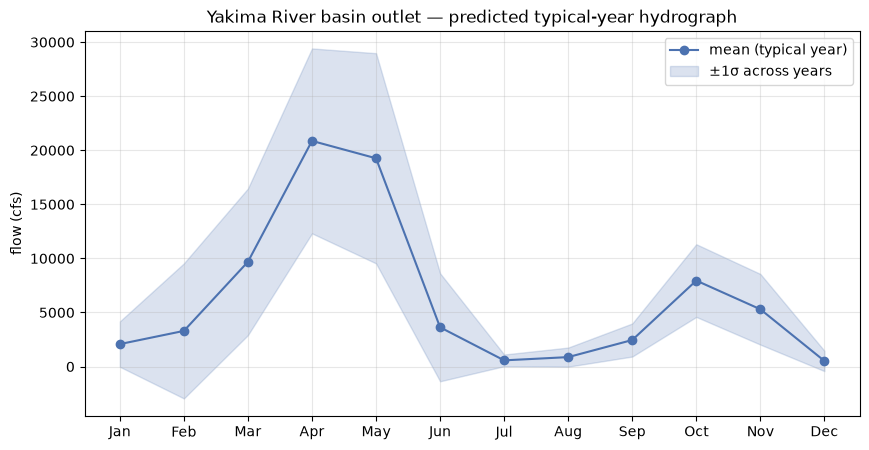

In [9]:
mean_month = flow.mean(axis=0)
std_month = flow.std(axis=0, ddof=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(MONTH_ABBR, mean_month, marker="o", color="#4c72b0",
        label="mean (typical year)")
ax.fill_between(MONTH_ABBR, mean_month - std_month, mean_month + std_month,
                alpha=0.2, color="#4c72b0", label="±1σ across years")
ax.set_ylabel("flow (cfs)")
ax.set_title(f"{BASIN_NAME} outlet — predicted typical-year hydrograph")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

### Notes & how to extend

- **Model, not gauge.** Flow is NHDPlus mean-annual discharge redistributed by PRISM climate — good for *relative* year-over-year and seasonal comparison, not absolute accuracy. Annual totals are conserved by design.
- **Try another basin:** change `HUC4` in the config cell — `1711` (Puget Sound / WA coast), `1708` (Lower Columbia), `1710`, `1702` (Upper Columbia), `1703` (Yakima). Cached networks live under `output/_yoy_net_*.pkl`.
- **More years:** stage more PRISM with `python tools/prism_fetch.py --start 1990 --end 2023 --vars ppt tmean` (record goes back to 1895), then widen `YEARS`.
- **Pick a different reach** instead of the outlet: e.g. the reach nearest a point, `outlet = int(((lon - -120.5)**2 + (lat - 46.6)**2).argmin())`.